Starting to load files...
Successfully loaded and sampled: 2023-1.parquet
Successfully loaded and sampled: 2023-2.parquet
Successfully loaded and sampled: 2023-3.parquet
Successfully loaded and sampled: 2023-4.parquet
Successfully loaded and sampled: 2023-5.parquet
Successfully loaded and sampled: 2023-6.parquet
Successfully loaded and sampled: 2023-7.parquet
Successfully loaded and sampled: 2023-8.parquet
Successfully loaded and sampled: 2023-9.parquet
Successfully loaded and sampled: 2023-10.parquet
Successfully loaded and sampled: 2023-11.parquet
Successfully loaded and sampled: 2023-12.parquet
Concatenating dataframes...
Data successfully loaded!

----------------------------------------
MISSING VALUES:
----------------------------------------
passenger_count           64924
RatecodeID                64924
store_and_fwd_flag        64924
congestion_surcharge      64924
airport_fee             1747907
Airport_fee              213444
dtype: int64

------------------------------------

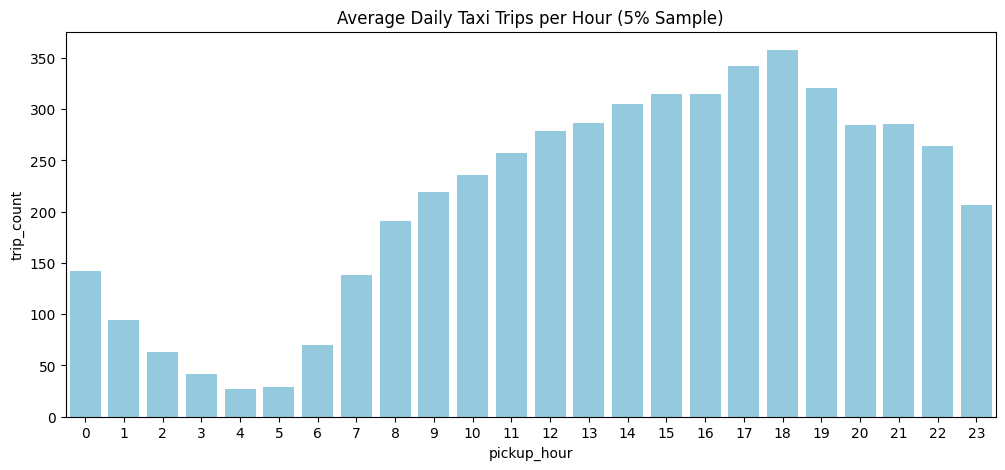

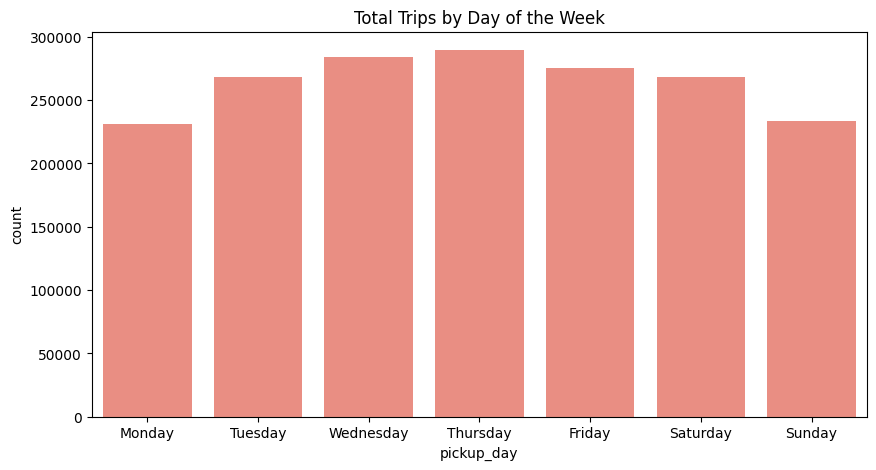

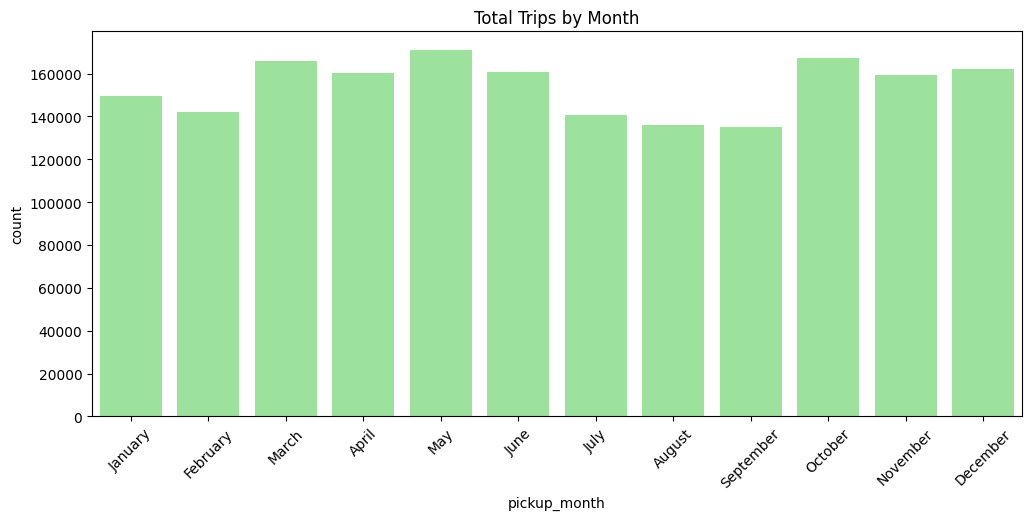

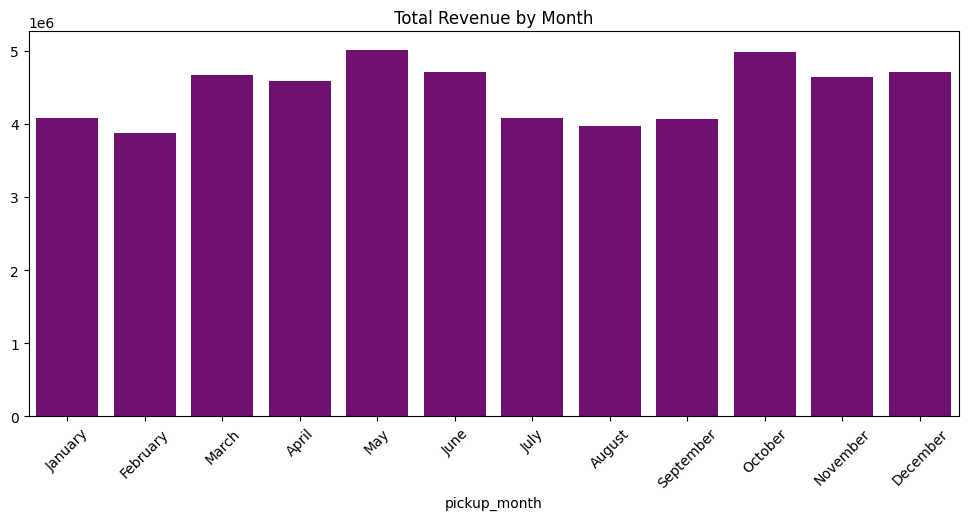

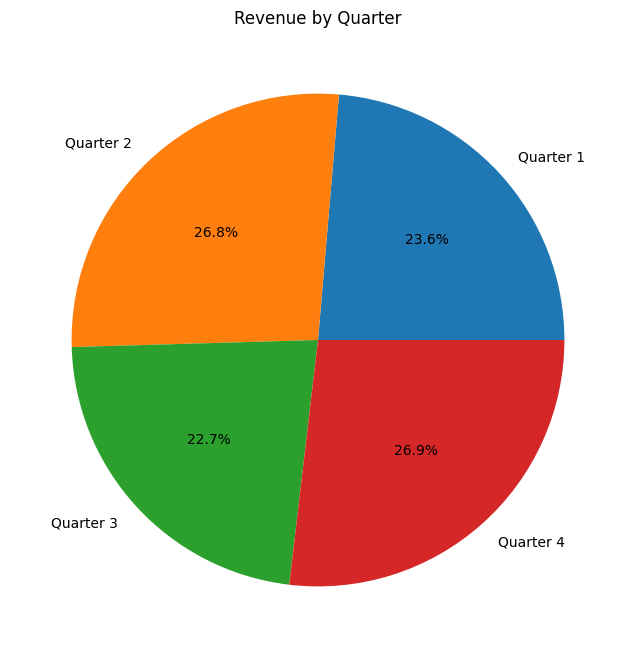

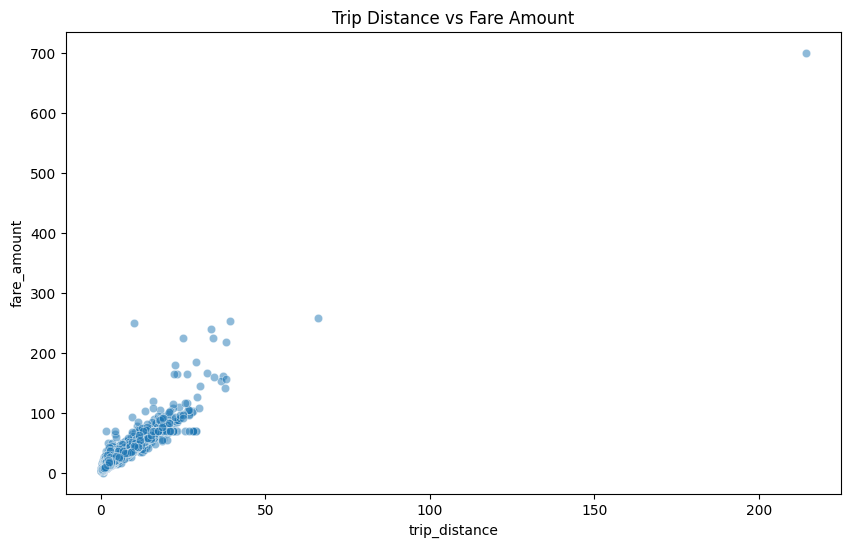

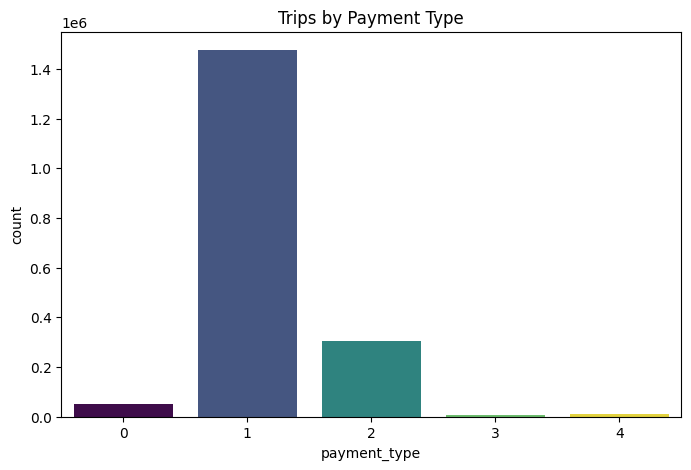

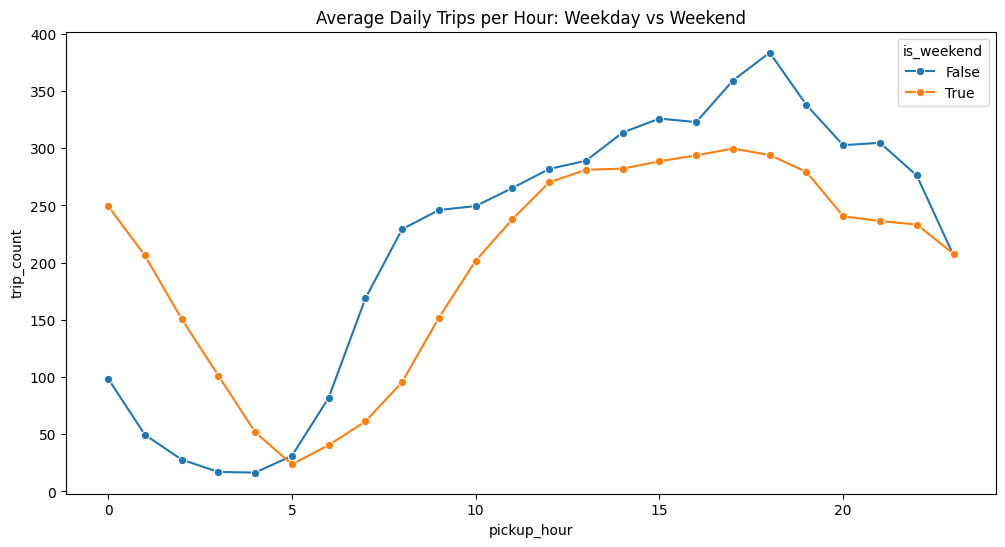

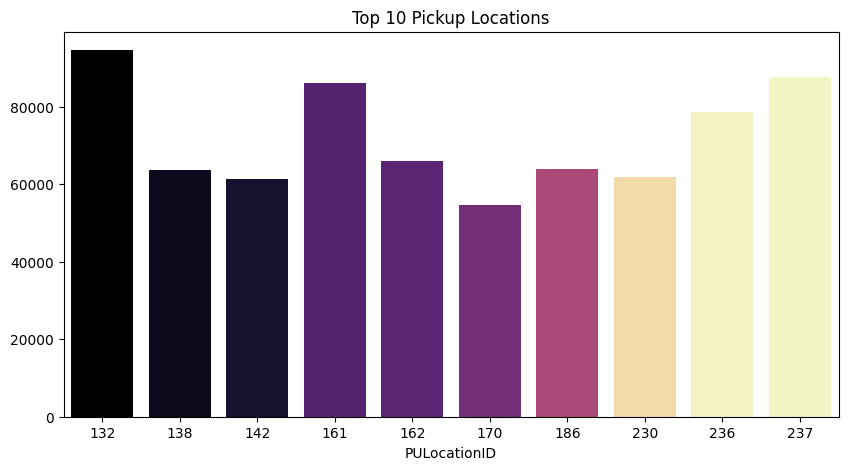

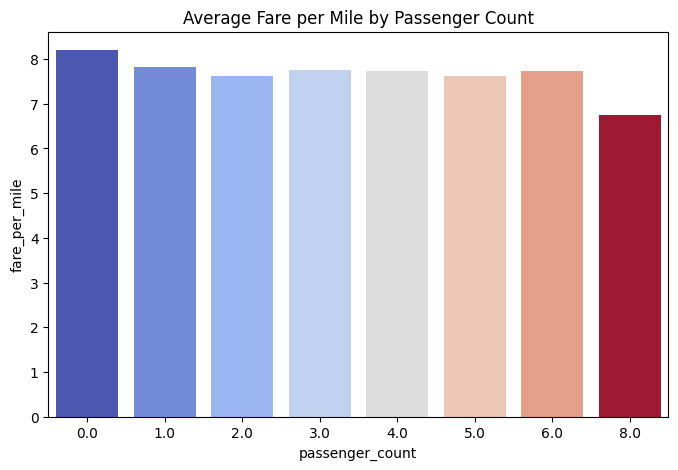

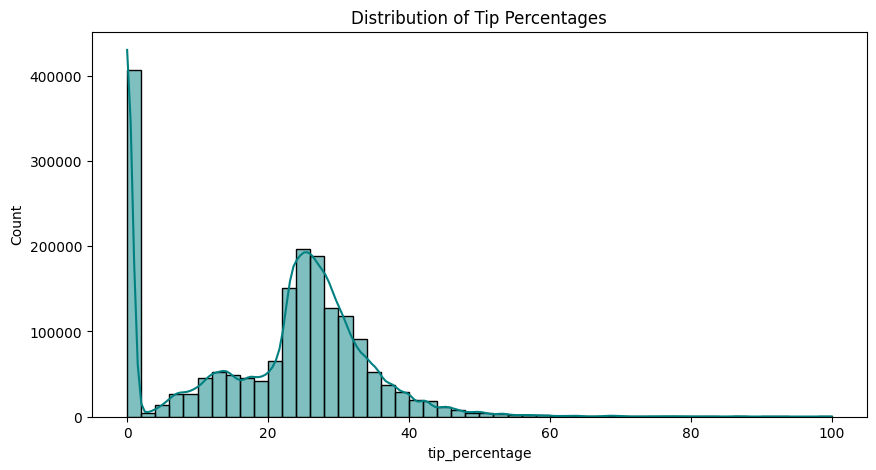

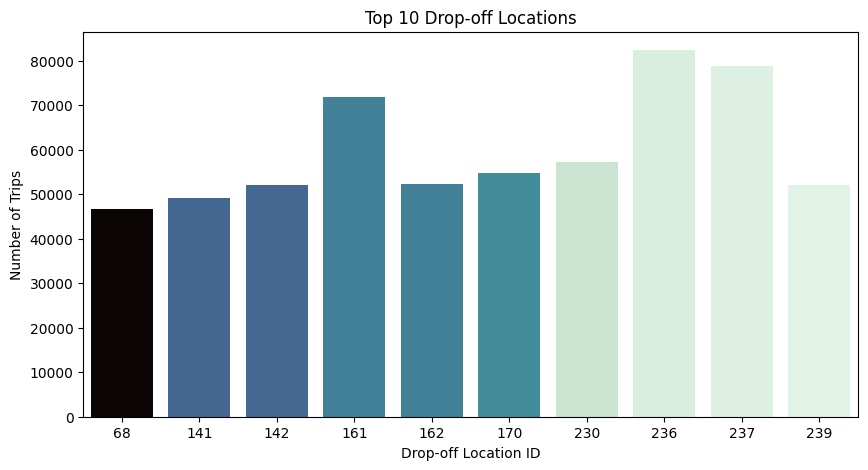

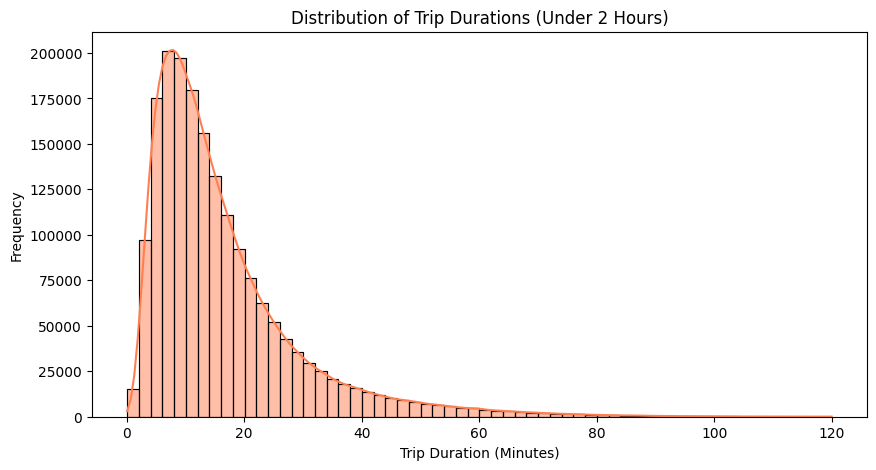

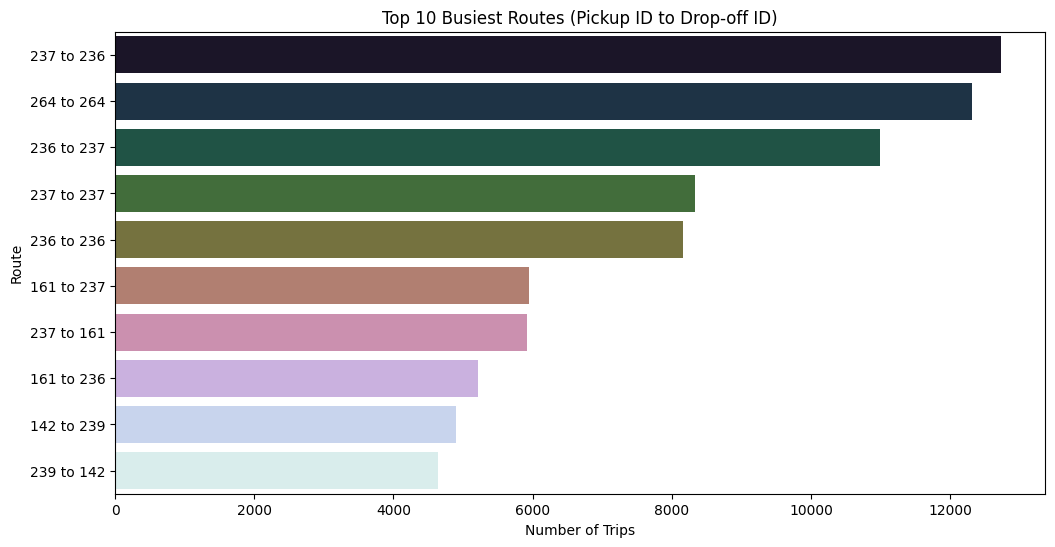

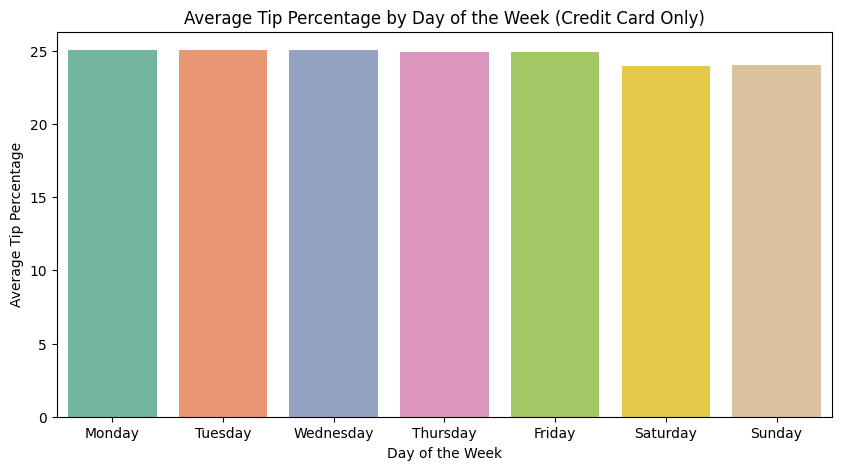

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------
# 1. Data Loading and Sampling
# ---------------------------------------------------------
folder_path = r"C:\Users\Keerthana\Downloads\Datasets and Dictionary-NYC\Datasets and Dictionary\trip_records"

# Exact file naming from your folder
file_paths = [rf"{folder_path}\2023-{month}.parquet" for month in range(1, 13)]

sampled_dataframes = []
sample_fraction = 0.05

print("Starting to load files...")

for file in file_paths:
    if not os.path.exists(file):
        print(f"Warning: File not found at {file}")
        continue
        
    try:
        df = pd.read_parquet(file)
        df_sampled = df.sample(frac=sample_fraction, random_state=42)
        sampled_dataframes.append(df_sampled)
        print(f"Successfully loaded and sampled: {os.path.basename(file)}")
    except Exception as e:
        print(f"Could not read {file}. Error: {e}")

if not sampled_dataframes:
    raise RuntimeError("CRITICAL ERROR: No dataframes were loaded. Check paths and pyarrow installation.")

print("Concatenating dataframes...")
master_df = pd.concat(sampled_dataframes, ignore_index=True)
print("Data successfully loaded!\n")

# ---------------------------------------------------------
# 2. Data Exploration & Summary 
# ---------------------------------------------------------
print("-" * 40)
print("MISSING VALUES:")
print("-" * 40)
missing_values = master_df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n" + "-" * 40)
print("SUMMARY STATISTICS:")
print("-" * 40)
print(master_df[['passenger_count', 'trip_distance', 'fare_amount', 'tip_amount']].describe())
print("\n")

# ---------------------------------------------------------
# 3. Data Cleaning & Feature Engineering
# ---------------------------------------------------------
master_df['tpep_pickup_datetime'] = pd.to_datetime(master_df['tpep_pickup_datetime'])
master_df['tpep_dropoff_datetime'] = pd.to_datetime(master_df['tpep_dropoff_datetime'])

master_df['pickup_hour'] = master_df['tpep_pickup_datetime'].dt.hour
master_df['pickup_day'] = master_df['tpep_pickup_datetime'].dt.day_name()
master_df['pickup_month'] = master_df['tpep_pickup_datetime'].dt.month_name()
master_df['quarter'] = master_df['tpep_pickup_datetime'].dt.quarter
master_df['pickup_date'] = master_df['tpep_pickup_datetime'].dt.date 
master_df['is_weekend'] = master_df['pickup_day'].isin(['Saturday', 'Sunday'])

master_df['trip_duration_mins'] = (master_df['tpep_dropoff_datetime'] - master_df['tpep_pickup_datetime']).dt.total_seconds() / 60

master_df = master_df[(master_df['fare_amount'] > 0) & 
                      (master_df['trip_distance'] > 0) & 
                      (master_df['tip_amount'] >= 0)]

master_df['avg_speed_mph'] = master_df['trip_distance'] / (master_df['trip_duration_mins'] / 60)
master_df = master_df[(master_df['avg_speed_mph'] > 0) & (master_df['avg_speed_mph'] < 100)]

master_df['fare_per_mile'] = master_df['fare_amount'] / master_df['trip_distance']
master_df = master_df[master_df['fare_per_mile'] < 50]

master_df['tip_percentage'] = (master_df['tip_amount'] / master_df['fare_amount']) * 100
master_df = master_df[master_df['tip_percentage'] <= 100]

# --- Create a Route Column (Pickup ID to Dropoff ID) ---
master_df['route'] = master_df['PULocationID'].astype(str) + " to " + master_df['DOLocationID'].astype(str)

# ---------------------------------------------------------
# 4. Visualizations
# ---------------------------------------------------------

# --- Plot 1: Average Daily Trips per Hour ---
trips_per_hour_daily = master_df.groupby(['pickup_date', 'pickup_hour']).size().reset_index(name='trip_count')
average_hourly_volume = trips_per_hour_daily.groupby('pickup_hour')['trip_count'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=average_hourly_volume, x='pickup_hour', y='trip_count', color='skyblue')
plt.title('Average Daily Taxi Trips per Hour (5% Sample)')
plt.show()

# --- Plot 2: Total Trips by Day of Week ---
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=master_df, x='pickup_day', order=days_order, color='salmon')
plt.title('Total Trips by Day of the Week')
plt.show()

# --- Plot 3: Total Trips by Month ---
plt.figure(figsize=(12, 5))
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=master_df, x='pickup_month', order=months_order, color='lightgreen')
plt.xticks(rotation=45)
plt.title('Total Trips by Month')
plt.show()

# --- Plot 4: Total Revenue by Month ---
if 'total_amount' in master_df.columns:
    monthly_revenue = master_df.groupby('pickup_month')['total_amount'].sum().reindex(months_order)
    plt.figure(figsize=(12, 5))
    sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, color='purple')
    plt.xticks(rotation=45)
    plt.title('Total Revenue by Month')
    plt.show()

# --- Plot 5: Revenue by Quarter ---
if 'total_amount' in master_df.columns:
    quarterly_revenue = master_df.groupby('quarter')['total_amount'].sum()
    plt.figure(figsize=(8, 8))
    plt.pie(quarterly_revenue, labels=[f"Quarter {q}" for q in quarterly_revenue.index], autopct='%1.1f%%')
    plt.title('Revenue by Quarter')
    plt.show()

# --- Plot 6: Distance vs Fare ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df.sample(min(10000, len(master_df)), random_state=42), x='trip_distance', y='fare_amount', alpha=0.5)
plt.title('Trip Distance vs Fare Amount')
plt.show()

# --- Plot 7: Payment Type ---
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x='payment_type', hue='payment_type', palette='viridis', legend=False)
plt.title('Trips by Payment Type')
plt.show()

# --- Plot 8: Average Hourly Traffic (Weekend vs Weekday) ---
daily_traffic_split = master_df.groupby(['pickup_date', 'pickup_hour', 'is_weekend']).size().reset_index(name='trip_count')
avg_hourly_traffic_split = daily_traffic_split.groupby(['pickup_hour', 'is_weekend'])['trip_count'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_hourly_traffic_split, x='pickup_hour', y='trip_count', hue='is_weekend', marker='o')
plt.title('Average Daily Trips per Hour: Weekday vs Weekend')
plt.show()

# --- Plot 9: Top Pickup Zones ---
top_pickup_zones = master_df['PULocationID'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_pickup_zones.index, y=top_pickup_zones.values, hue=top_pickup_zones.index, palette='magma', legend=False)
plt.title('Top 10 Pickup Locations')
plt.show()

# --- Plot 10: Fare per Mile by Passenger Count ---
fare_by_passenger = master_df.groupby('passenger_count')['fare_per_mile'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=fare_by_passenger, x='passenger_count', y='fare_per_mile', hue='passenger_count', palette='coolwarm', legend=False)
plt.title('Average Fare per Mile by Passenger Count')
plt.show()

# --- Plot 11: Tip Percentage Distribution ---
plt.figure(figsize=(10, 5))
sns.histplot(master_df['tip_percentage'], bins=50, kde=True, color='teal')
plt.title('Distribution of Tip Percentages')
plt.show()

# ---------------------------------------------------------
# NEW ADDITIONS
# ---------------------------------------------------------

# --- Plot 12: Top Drop-off Zones ---
top_dropoff_zones = master_df['DOLocationID'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_dropoff_zones.index, y=top_dropoff_zones.values, hue=top_dropoff_zones.index, palette='mako', legend=False)
plt.title('Top 10 Drop-off Locations')
plt.xlabel('Drop-off Location ID')
plt.ylabel('Number of Trips')
plt.show()

# --- Plot 13: Trip Duration Distribution ---
# Filtering out trips over 2 hours just so the graph is readable
realistic_durations = master_df[master_df['trip_duration_mins'] < 120]
plt.figure(figsize=(10, 5))
sns.histplot(realistic_durations['trip_duration_mins'], bins=60, kde=True, color='coral')
plt.title('Distribution of Trip Durations (Under 2 Hours)')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

# --- Plot 14: Top 10 Most Common Routes ---
top_routes = master_df['route'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_routes.index, x=top_routes.values, hue=top_routes.index, palette='cubehelix', legend=False)
plt.title('Top 10 Busiest Routes (Pickup ID to Drop-off ID)')
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.show()

# --- Plot 15: Average Tip Percentage by Day of the Week ---
# Using payment_type == 1 because NYC taxis only reliably record tips paid by credit card
credit_card_trips = master_df[master_df['payment_type'] == 1]
avg_tip_by_day = credit_card_trips.groupby('pickup_day')['tip_percentage'].mean().reindex(days_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_tip_by_day, x='pickup_day', y='tip_percentage', hue='pickup_day', palette='Set2', legend=False)
plt.title('Average Tip Percentage by Day of the Week (Credit Card Only)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Tip Percentage')
plt.show()